# Preprocessing and Dimensionality Reduction with PCA

**Global Geological Risk Analysis** — complete preprocessing pipeline, exploratory data analysis, PCA, and geospatial visualization.

**Author:** Persona 4 (Duo B)

### Pipeline overview
1. **Data ingestion** — load and spatially aggregate (H3) cyclones, volcanoes and Spain seismic events
2. **Exploratory analysis** — missing values, distributions, outliers, correlation
3. **Transformations** — log1p for high skew, one-hot encoding, StandardScaler
4. **PCA** — dimensionality reduction with variance retention analysis
5. **Export** — trained sklearn pipeline (joblib), processed datasets

### Checklist coverage
- Missing value analysis documented
- Outliers treated as high-value signal (not removed)
- Distribution visualisation per feature
- Correlation matrix — justifies PCA (correlated variables)
- Scaling justification — distances in clustering
- PCA: components, variance, technical justification
- 2D/3D visualisation of principal components


## 1. Library Imports and Environment Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_combined_data
from src.preprocessing import preprocessing_pca_pipeline, load_pipeline, detect_skew_columns
from src.visualization import (
    plot_cumulative_variance, plot_pca_2d, plot_biplot, plot_pca_interactive,
    plot_risk_map, plot_pairplot_pca, plot_loadings_heatmap, plot_pca_3d,
)

sns.set_theme(style="whitegrid", context="paper", font="sans-serif",
              font_scale=1.2, palette="mako")
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300,
                      "savefig.bbox": "tight"})
os.makedirs("figures", exist_ok=True)
print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Data Ingestion

Loading and spatially aggregating (H3 resolution 4) the three clean datasets:
- **IBTrACS cyclones** — global tropical cyclone tracks
- **NOAA volcanoes** — significant volcanic eruptions
- **IGN Spain** — seismic catalogue for Spain and Canary Islands

In [2]:
df_raw = load_combined_data()
print(f"Rows (H3 cells): {df_raw.shape[0]:,}")
print(f"Columns: {list(df_raw.columns)}")
print(f"Memory: {df_raw.memory_usage(deep=True).sum() / 1024 ** 2:.1f} MB")
print(f"\nLat range: [{df_raw['lat'].min():.2f}, {df_raw['lat'].max():.2f}]")
print(f"Lon range: [{df_raw['lon'].min():.2f}, {df_raw['lon'].max():.2f}]")
df_raw.head()

Rows (H3 cells): 41,162
Columns: ['cell_id', 'lat', 'lon', 'eq_count', 'eq_mag_mean', 'eq_mag_max', 'eq_depth_mean', 'eq_energy_log', 'eq_days_since_last_major', 'cyclone_count', 'wind_mean', 'wind_max', 'pressure_min_mean', 'dist_nearest_volcano_km', 'volcano_count', 'categoria_tormenta']
Memory: 8.9 MB

Lat range: [-89.61, 89.62]
Lon range: [-180.00, 180.00]


,cell_id,lat,lon,eq_count,eq_mag_mean,eq_mag_max,eq_depth_mean,eq_energy_log,eq_days_since_last_major,cyclone_count,wind_mean,wind_max,pressure_min_mean,dist_nearest_volcano_km,volcano_count,categoria_tormenta
0,830d83fffffffff,66.541996,-175.333902,3.0,5.00,5.3,9.766667,12.905037,99999.0,0.0,0.000000,0.0,1013.000000,9133.832542,0,TD
1,832969fffffffff,34.792390,-136.442913,0.0,0.00,0.0,0.000000,0.000000,99999.0,0.0,0.000000,0.0,1013.000000,7098.227049,0,TD
2,83722efffffffff,6.739360,138.817498,0.0,0.00,0.0,0.000000,0.000000,99999.0,94.0,36.630435,50.0,1002.902597,1330.522393,0,TS
3,8314b1fffffffff,48.255967,125.684028,0.0,0.00,0.0,0.000000,0.000000,99999.0,0.0,0.000000,0.0,1013.000000,1797.757383,0,TD
4,836803fffffffff,6.893151,117.880300,2.0,5.25,5.4,42.000000,13.031879,99999.0,5.0,35.000000,35.0,1004.500000,702.621529,0,TS


## 3. Exploratory Data Analysis

### 3.1 Missing Values

Understanding sparsity is critical. A cell with no cyclone records may mean no storm passed there (true zero) or sparse historical tracking (sensor coverage bias).

In [3]:
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
excluir = {"lat", "lon", "h3_index", "cell_id"}
features = [c for c in num_cols if c not in excluir]

null_stats = pd.DataFrame({
    "null_count": df_raw[features].isnull().sum(),
    "null_pct": (df_raw[features].isnull().sum() / len(df_raw) * 100).round(2),
})
null_stats = null_stats[null_stats["null_count"] > 0]

if len(null_stats) > 0:
    print("Features with missing values:")
    display(null_stats.sort_values("null_pct", ascending=False))
else:
    print("No missing values in numeric features.")

print(f"\nTotal rows: {len(df_raw):,}")
print(f"Complete cases: {df_raw[features].dropna().shape[0]:,}")

No missing values in numeric features.

Total rows: 41,162
Complete cases: 41,162


### 3.2 Feature Distributions

High skew is visible in: earthquake magnitude (exponential), volcano elevation (right-skewed).

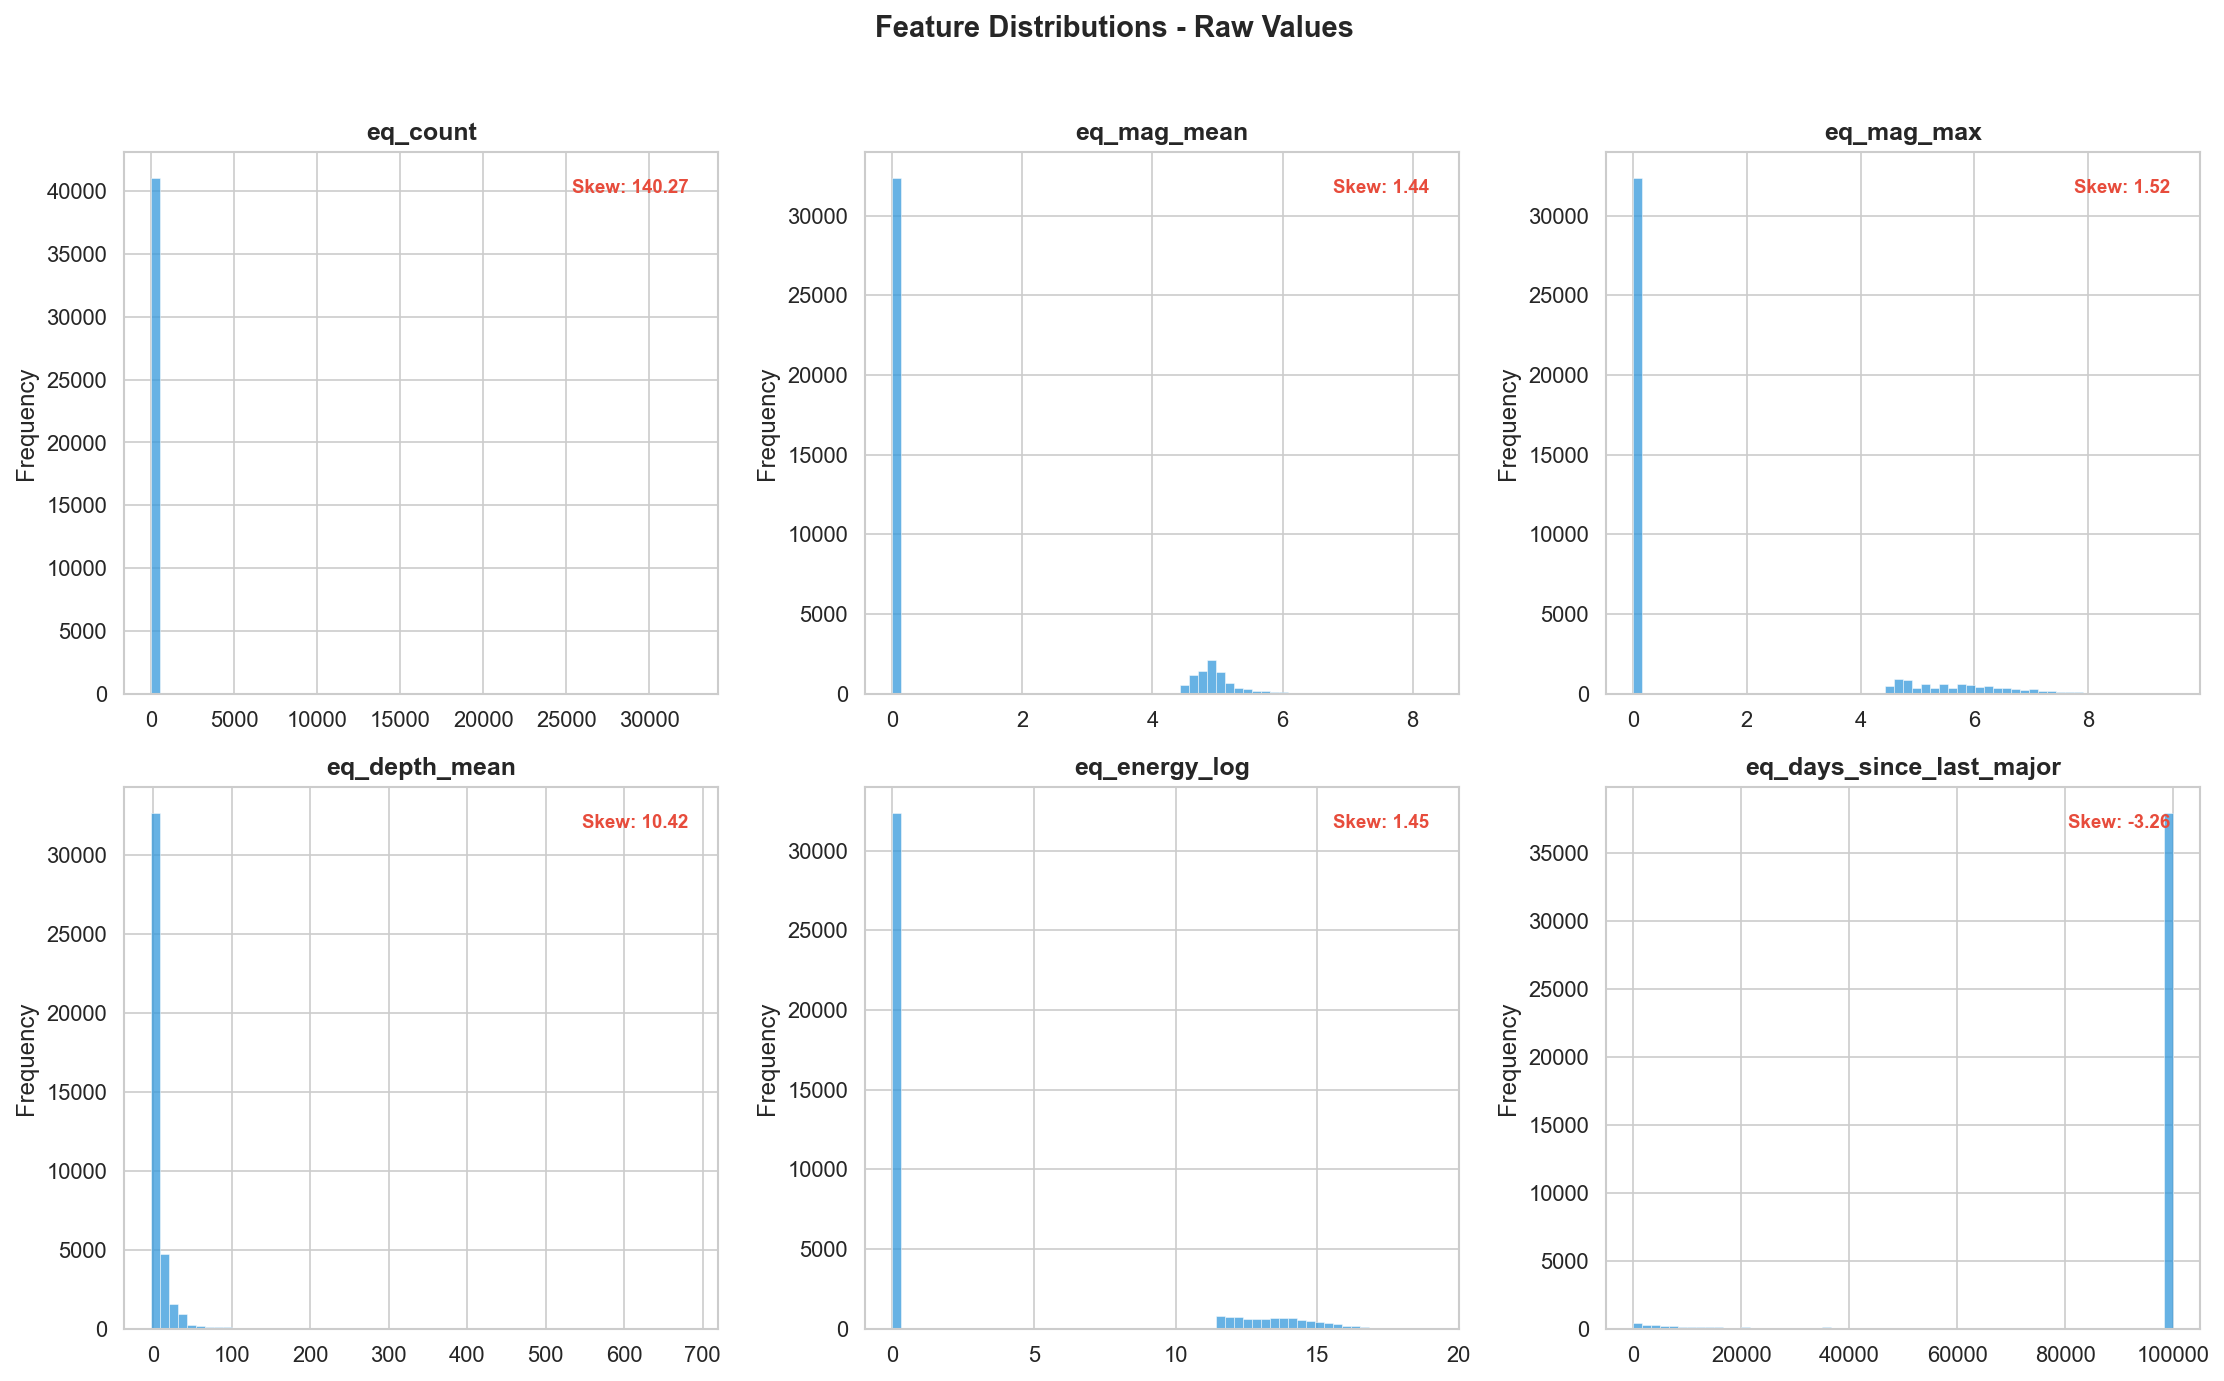

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

titles_map = {
    "magnitud_max_sismo": "Max Earthquake Magnitude",
    "profundidad_media_sismo": "Mean Depth (km)",
    "frecuencia_eventos_sismicos": "Seismic Event Count",
    "viento_max_ciclones": "Max Wind Speed (knots)",
    "presion_min_ciclones": "Min Pressure (mb)",
    "elevacion_volcan": "Volcano Elevation (m)",
}

for ax, col in zip(axes, features):
    if col in df_raw.columns:
        data = df_raw[col].dropna()
        ax.hist(data, bins=60, color="#3498db", edgecolor="white",
                alpha=0.75, linewidth=0.3)
        ax.set_title(titles_map.get(col, col), fontsize=12, weight="bold")
        ax.set_ylabel("Frequency")
        skew_val = data.skew()
        ax.text(0.95, 0.95, f"Skew: {skew_val:.2f}",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=9, color="#e74c3c", weight="bold")

fig.suptitle("Feature Distributions - Raw Values", fontsize=14, weight="bold", y=1.02)
fig.tight_layout()
fig.savefig("figures/feature_distributions.png", dpi=300)
plt.show()

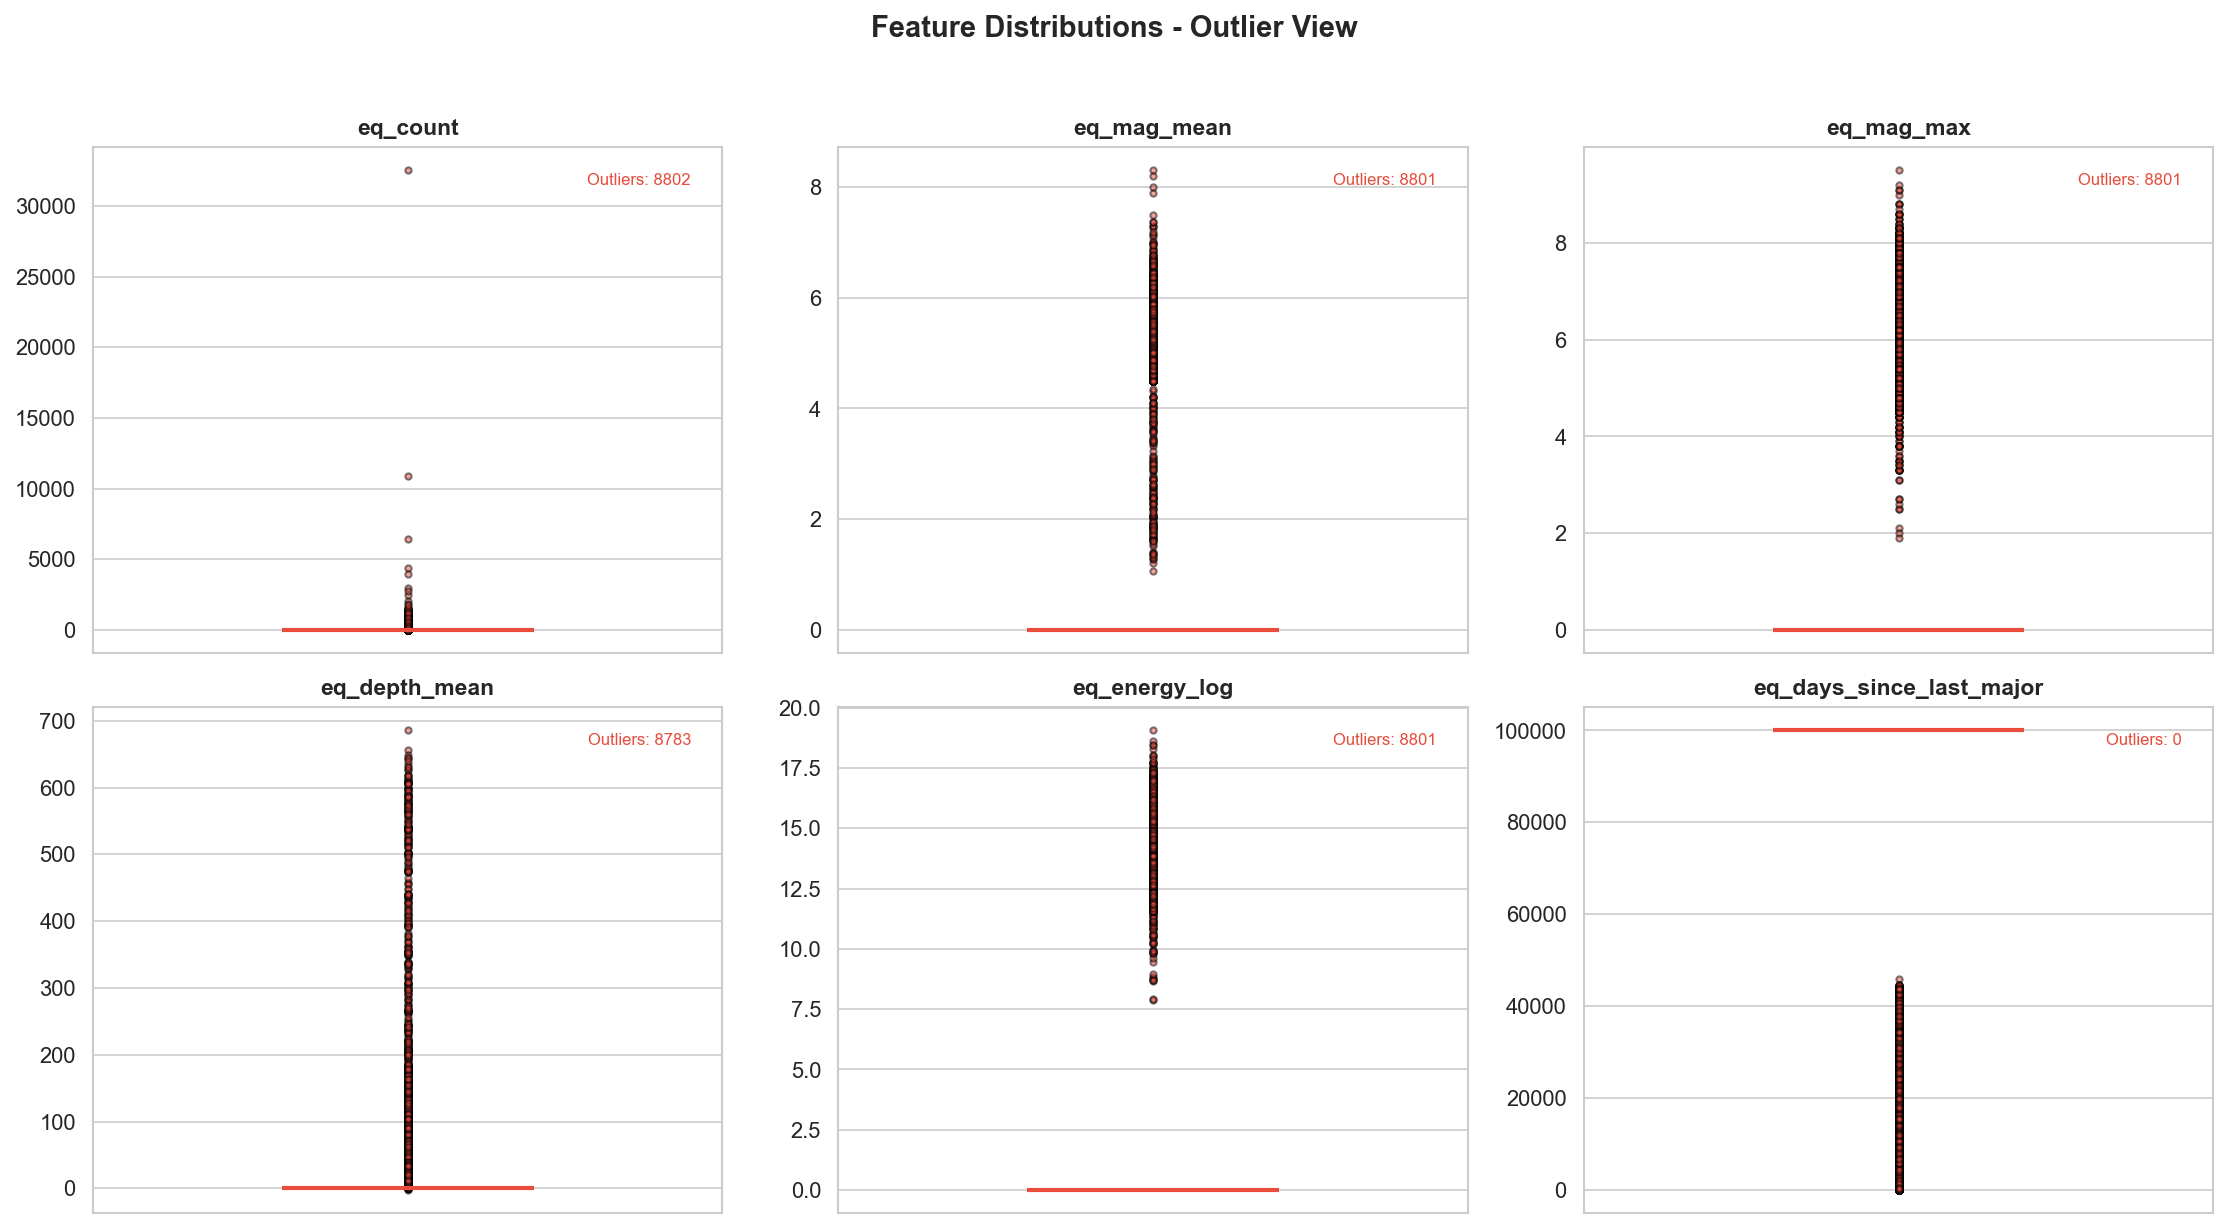

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, features):
    if col in df_raw.columns:
        data = df_raw[col].dropna()
        ax.boxplot(data, vert=True, patch_artist=True, widths=0.4,
                   boxprops=dict(facecolor="#3498db", alpha=0.6),
                   medianprops=dict(color="#e74c3c", linewidth=2),
                   whiskerprops=dict(linewidth=1.2),
                   capprops=dict(linewidth=1.2),
                   flierprops=dict(marker="o", markersize=3,
                                   markerfacecolor="#e74c3c", alpha=0.5))
        ax.set_title(titles_map.get(col, col), fontsize=11, weight="bold")
        q1, q3 = data.quantile(0.25), data.quantile(0.75)
        iqr = q3 - q1
        n_outliers = (data > q3 + 1.5 * iqr).sum()
        ax.text(0.95, 0.95, f"Outliers: {n_outliers}",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=8, color="#e74c3c")
        ax.set_xticks([])

fig.suptitle("Feature Distributions - Outlier View", fontsize=14, weight="bold", y=1.02)
fig.tight_layout()
fig.savefig("figures/feature_boxplots.png", dpi=300)
plt.show()

### 3.3 Outlier Treatment — Signal, Not Noise

In geological risk, extreme values are the most informative observations:
- A cell with magnitude 9.0+ earthquakes is a subduction zone, not an error
- A volcano with 6000 m elevation is high risk, not anomalous data

**Outliers are preserved as high-value signals.** Log1p reduces leverage without removal. DBSCAN (Persona 5) can isolate extreme cells as noise clusters — this is a feature, not a bug (project checklist requirement).

In [6]:
outlier_counts = []
for col in features:
    if col in df_raw.columns:
        q1, q3 = df_raw[col].quantile(0.25), df_raw[col].quantile(0.75)
        iqr = q3 - q1
        outliers = ((df_raw[col] < q1 - 1.5 * iqr) | (df_raw[col] > q3 + 1.5 * iqr)).sum()
        outlier_counts.append({"feature": titles_map.get(col, col),
                               "n_outliers": outliers,
                               "pct": f"{outliers / len(df_raw) * 100:.2f}%"})

outlier_df = pd.DataFrame(outlier_counts)
display(outlier_df)
print("Decision: All outliers retained as high-value risk signals.")

,feature,n_outliers,pct
0,eq_count,8802,21.38%
1,eq_mag_mean,8801,21.38%
2,eq_mag_max,8801,21.38%
3,eq_depth_mean,8786,21.34%
4,eq_energy_log,8801,21.38%
5,eq_days_since_last_major,3238,7.87%
6,cyclone_count,6468,15.71%
7,wind_mean,11,0.03%
8,wind_max,487,1.18%
9,pressure_min_mean,513,1.25%


Decision: All outliers retained as high-value risk signals.


### 3.4 Correlation Matrix — Justification for PCA

PCA exploits variable correlation to find a lower-dimensional representation.
- Wind speed vs Min pressure: strong negative correlation (cyclone physics)
- Magnitude vs Depth: mild positive correlation
- Frequency vs Others: generally weak (independent hazard sources)

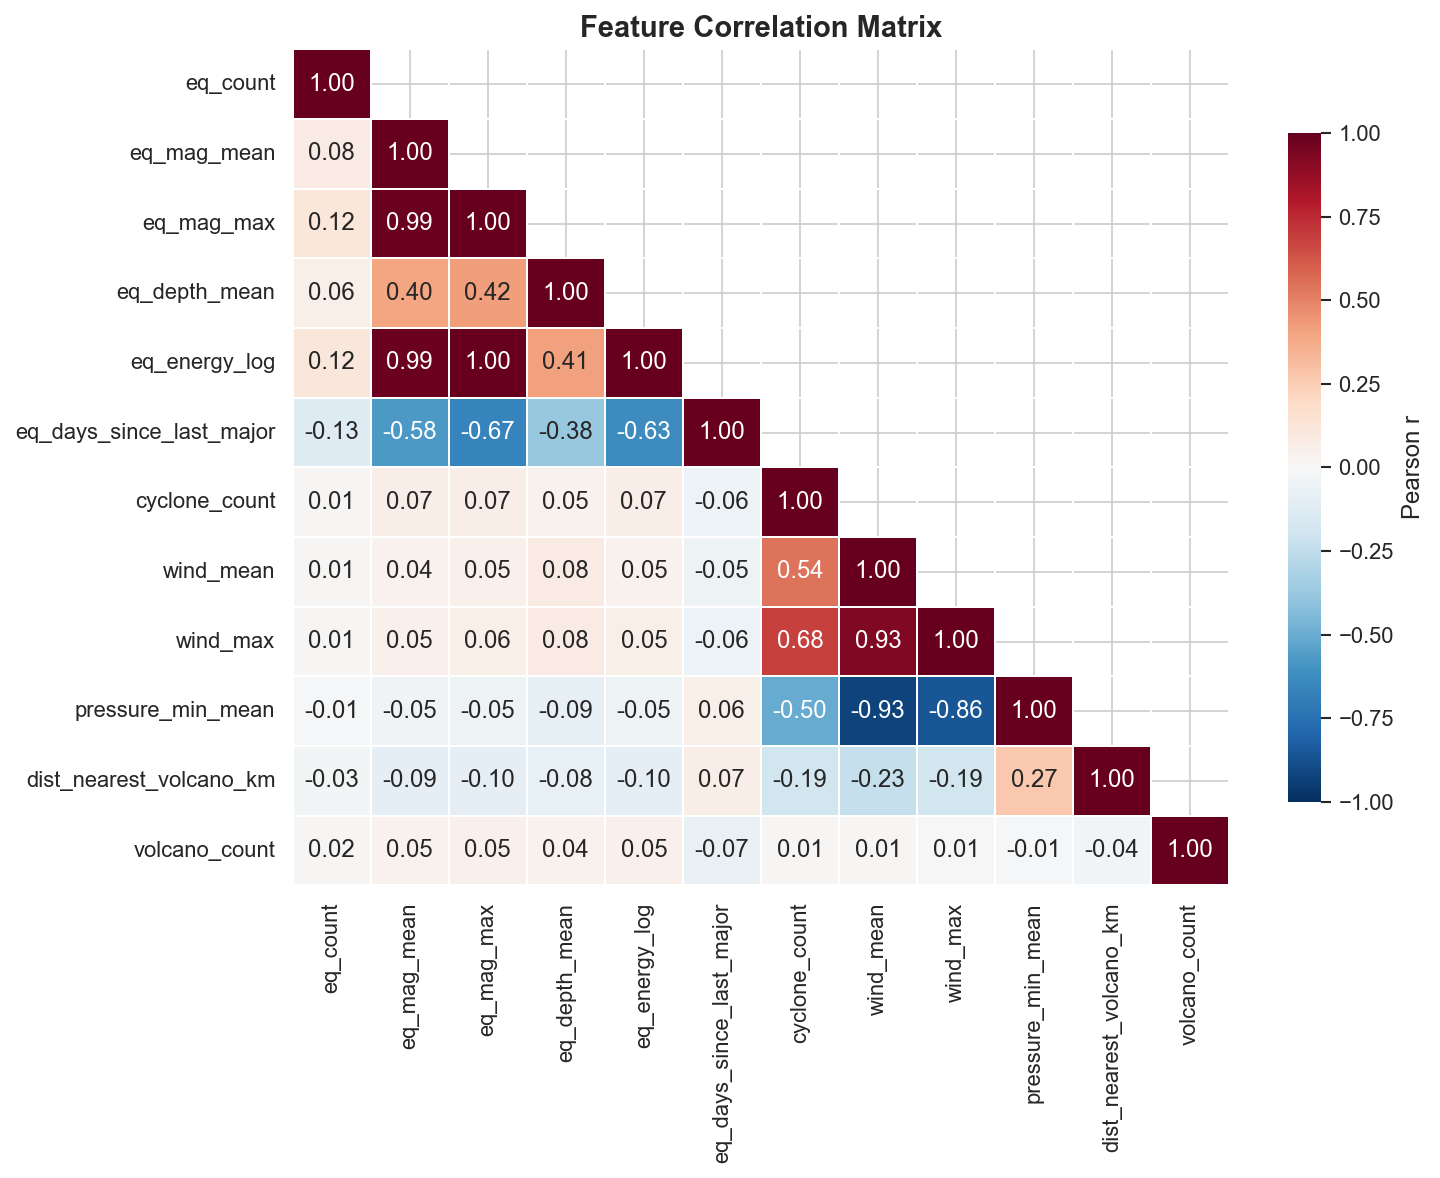

Mean absolute inter-feature correlation: 0.199
PCA is justified: variables show non-negligible correlation structure.


In [7]:
corr_matrix = df_raw[features].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, linewidths=0.8,
    xticklabels=[titles_map.get(c, c) for c in features],
    yticklabels=[titles_map.get(c, c) for c in features],
    cbar_kws={"label": "Pearson r", "shrink": 0.8}, ax=ax
)
ax.set_title("Feature Correlation Matrix", fontsize=14, weight="bold")
fig.tight_layout()
fig.savefig("figures/correlation_matrix.png", dpi=300)
plt.show()

corr_vals = corr_matrix.abs().values
np.fill_diagonal(corr_vals, 0)
mean_abs_corr = corr_vals.mean()
print(f"Mean absolute inter-feature correlation: {mean_abs_corr:.3f}")
print("PCA is justified: variables show non-negligible correlation structure.")

## 4. Logarithmic Transformation (log1p)

Columns with absolute skew > 0.75 receive log1p to reduce asymmetry and stabilise variance.

High-skew columns (>0.75): ['eq_count', 'eq_mag_mean', 'eq_mag_max', 'eq_depth_mean', 'eq_energy_log', 'eq_days_since_last_major', 'cyclone_count', 'wind_mean', 'wind_max', 'pressure_min_mean', 'volcano_count']
Below threshold: ['dist_nearest_volcano_km']


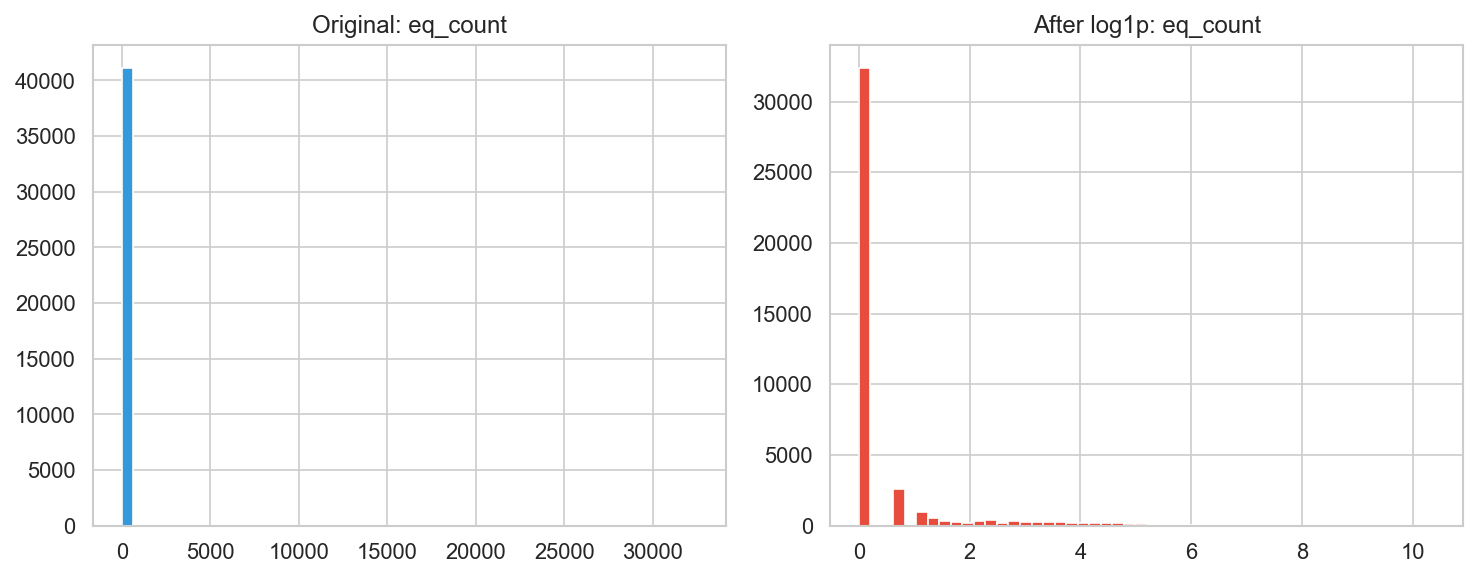

Skew before: 140.268 -> after: 2.885


In [8]:
skew_cols = detect_skew_columns(df_raw[features], threshold=0.75)
print(f"High-skew columns (>0.75): {skew_cols}")
print(f"Below threshold: {[c for c in features if c not in skew_cols]}")

if skew_cols:
    col = skew_cols[0]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(df_raw[col].dropna(), bins=50, color="#3498db", edgecolor="white")
    axes[0].set_title(f"Original: {titles_map.get(col, col)}")
    log_data = np.log1p(df_raw[col].clip(lower=0).dropna())
    axes[1].hist(log_data, bins=50, color="#e74c3c", edgecolor="white")
    axes[1].set_title(f"After log1p: {titles_map.get(col, col)}")
    fig.tight_layout()
    fig.savefig("figures/log1p_effect.png", dpi=300)
    plt.show()
    print(f"Skew before: {df_raw[col].skew():.3f} -> after: {log_data.skew():.3f}")

## 5. Scaling Justification

Clustering (K-Means, DBSCAN) relies on Euclidean distance. Features with different units would dominate distances purely by scale.

**StandardScaler** (mean=0, variance=1) ensures equal contribution. This is mandatory before PCA and distance-based clustering.

In [9]:
scale_summary = df_raw[features].describe().T[["mean", "std", "min", "max"]]
print("Scale disparity (before scaling):")
display(scale_summary)

from sklearn.preprocessing import StandardScaler
scaler_check = StandardScaler()
X_check = scaler_check.fit_transform(df_raw[features].fillna(df_raw[features].median()))
print(f"\nAfter StandardScaler: mean = {X_check.mean():.6f}, std = {X_check.std():.6f}")
print("All features now contribute equally to Euclidean distances.")

Scale disparity (before scaling):


,mean,std,min,max
eq_count,9.837301,184.486087,0.0000,32525.000000
eq_mag_mean,1.058005,2.041908,0.0000,8.300000
eq_mag_max,1.221297,2.380314,0.0000,9.500000
eq_depth_mean,8.395507,41.342366,-2.5400,685.500000
eq_energy_log,2.902069,5.604074,0.0000,19.055954
eq_days_since_last_major,93335.283247,23094.759646,6.0000,99999.000000
cyclone_count,9.204242,22.810166,0.0000,273.000000
wind_mean,16.337837,21.709457,0.0000,115.000000
wind_max,26.089108,37.713520,0.0000,185.000000
pressure_min_mean,1004.894214,11.946698,925.0000,1021.000000



After StandardScaler: mean = 0.000000, std = 1.000000
All features now contribute equally to Euclidean distances.


## 6. Full Preprocessing Pipeline

1. SkewLogTransformer — auto-detect high skew, apply log1p
2. OneHotEncoder — Saffir-Simpson storm category
3. StandardScaler — zero mean, unit variance
4. PCA — retain ~85% variance, dynamic component selection

In [10]:
df_pca, pipeline, df_scaled = preprocessing_pca_pipeline(
    df_raw, target_variance=0.85, save_path="models/pipeline_riesgo.joblib"
)

pca = pipeline.named_steps["pca"]
explained = pca.explained_variance_ratio_
cum_var = np.cumsum(explained)
n_keep = df_pca.shape[1]

print(f"PCA components retained: {n_keep}")
print(f"Total explained variance: {cum_var[n_keep-1]*100:.2f}%")
for i in range(n_keep):
    print(f"  PC{i+1}: {explained[i]*100:.2f}%")
print(f"\nPipeline exported to models/pipeline_riesgo.joblib")

PCA components retained: 4
Total explained variance: 88.49%
  PC1: 41.44%
  PC2: 31.73%
  PC3: 8.17%
  PC4: 7.15%

Pipeline exported to models/pipeline_riesgo.joblib


### 6.1 Cumulative Explained Variance

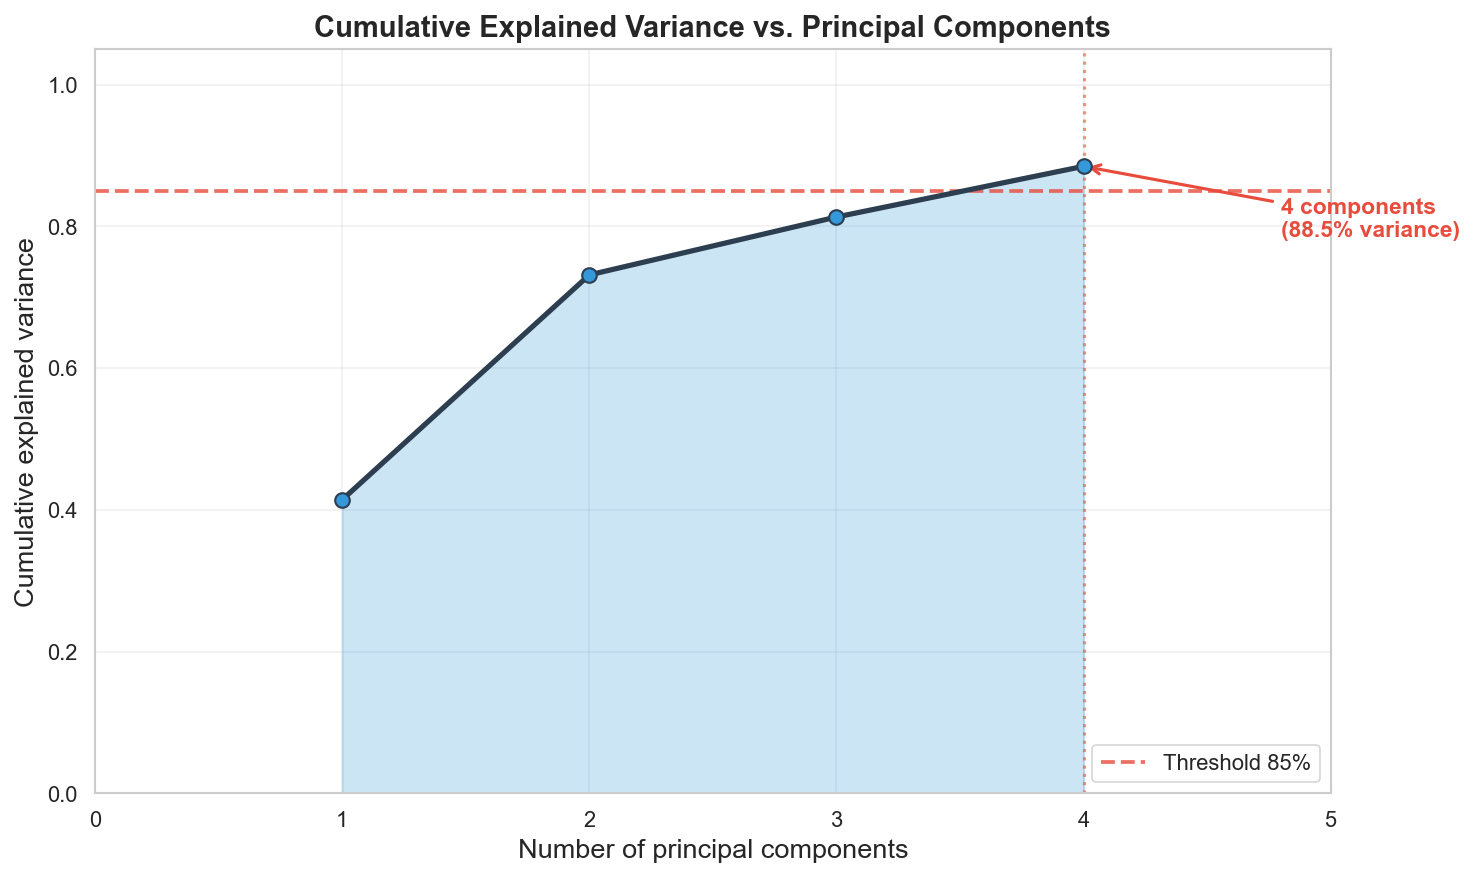

In [11]:
fig = plot_cumulative_variance(pca, threshold=0.85, save_path='figures/varianza_acumulada.png')
plt.show()

### 6.2 2D Projection — PC1 vs PC2

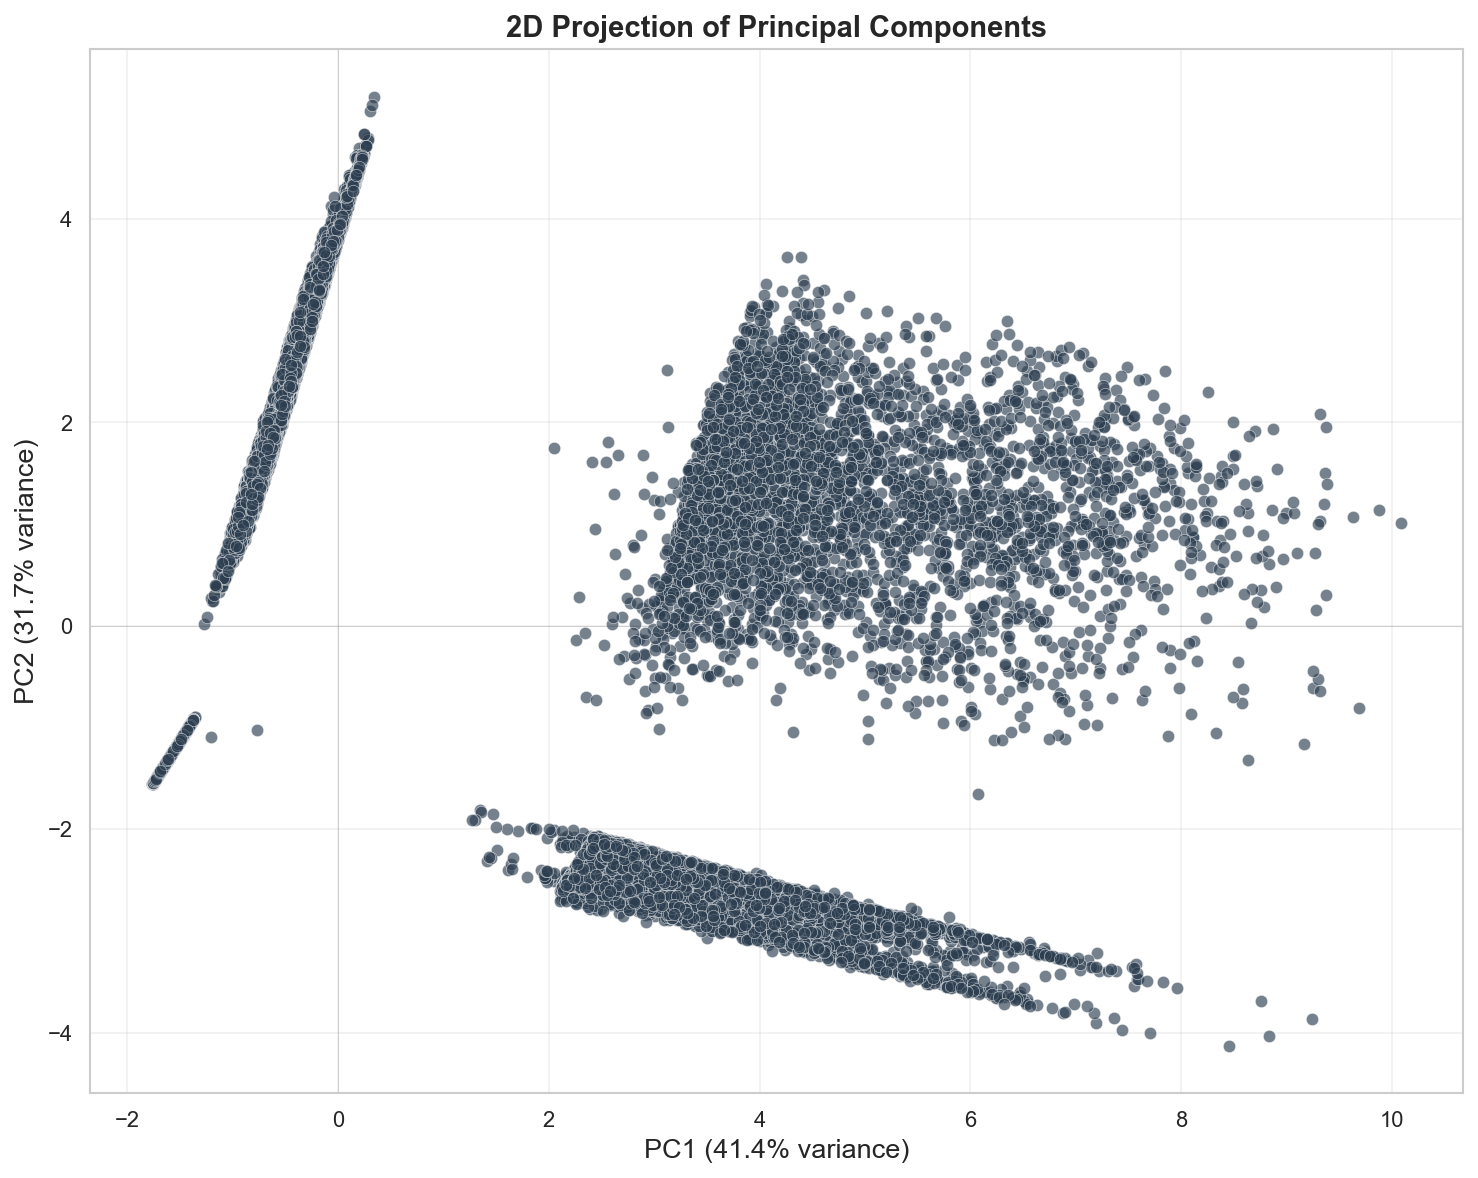

In [12]:
fig = plot_pca_2d(df_pca, pca_model=pca, save_path='figures/pca_2d.png')
plt.show()

### 6.3 Biplot — Original Variable Contributions

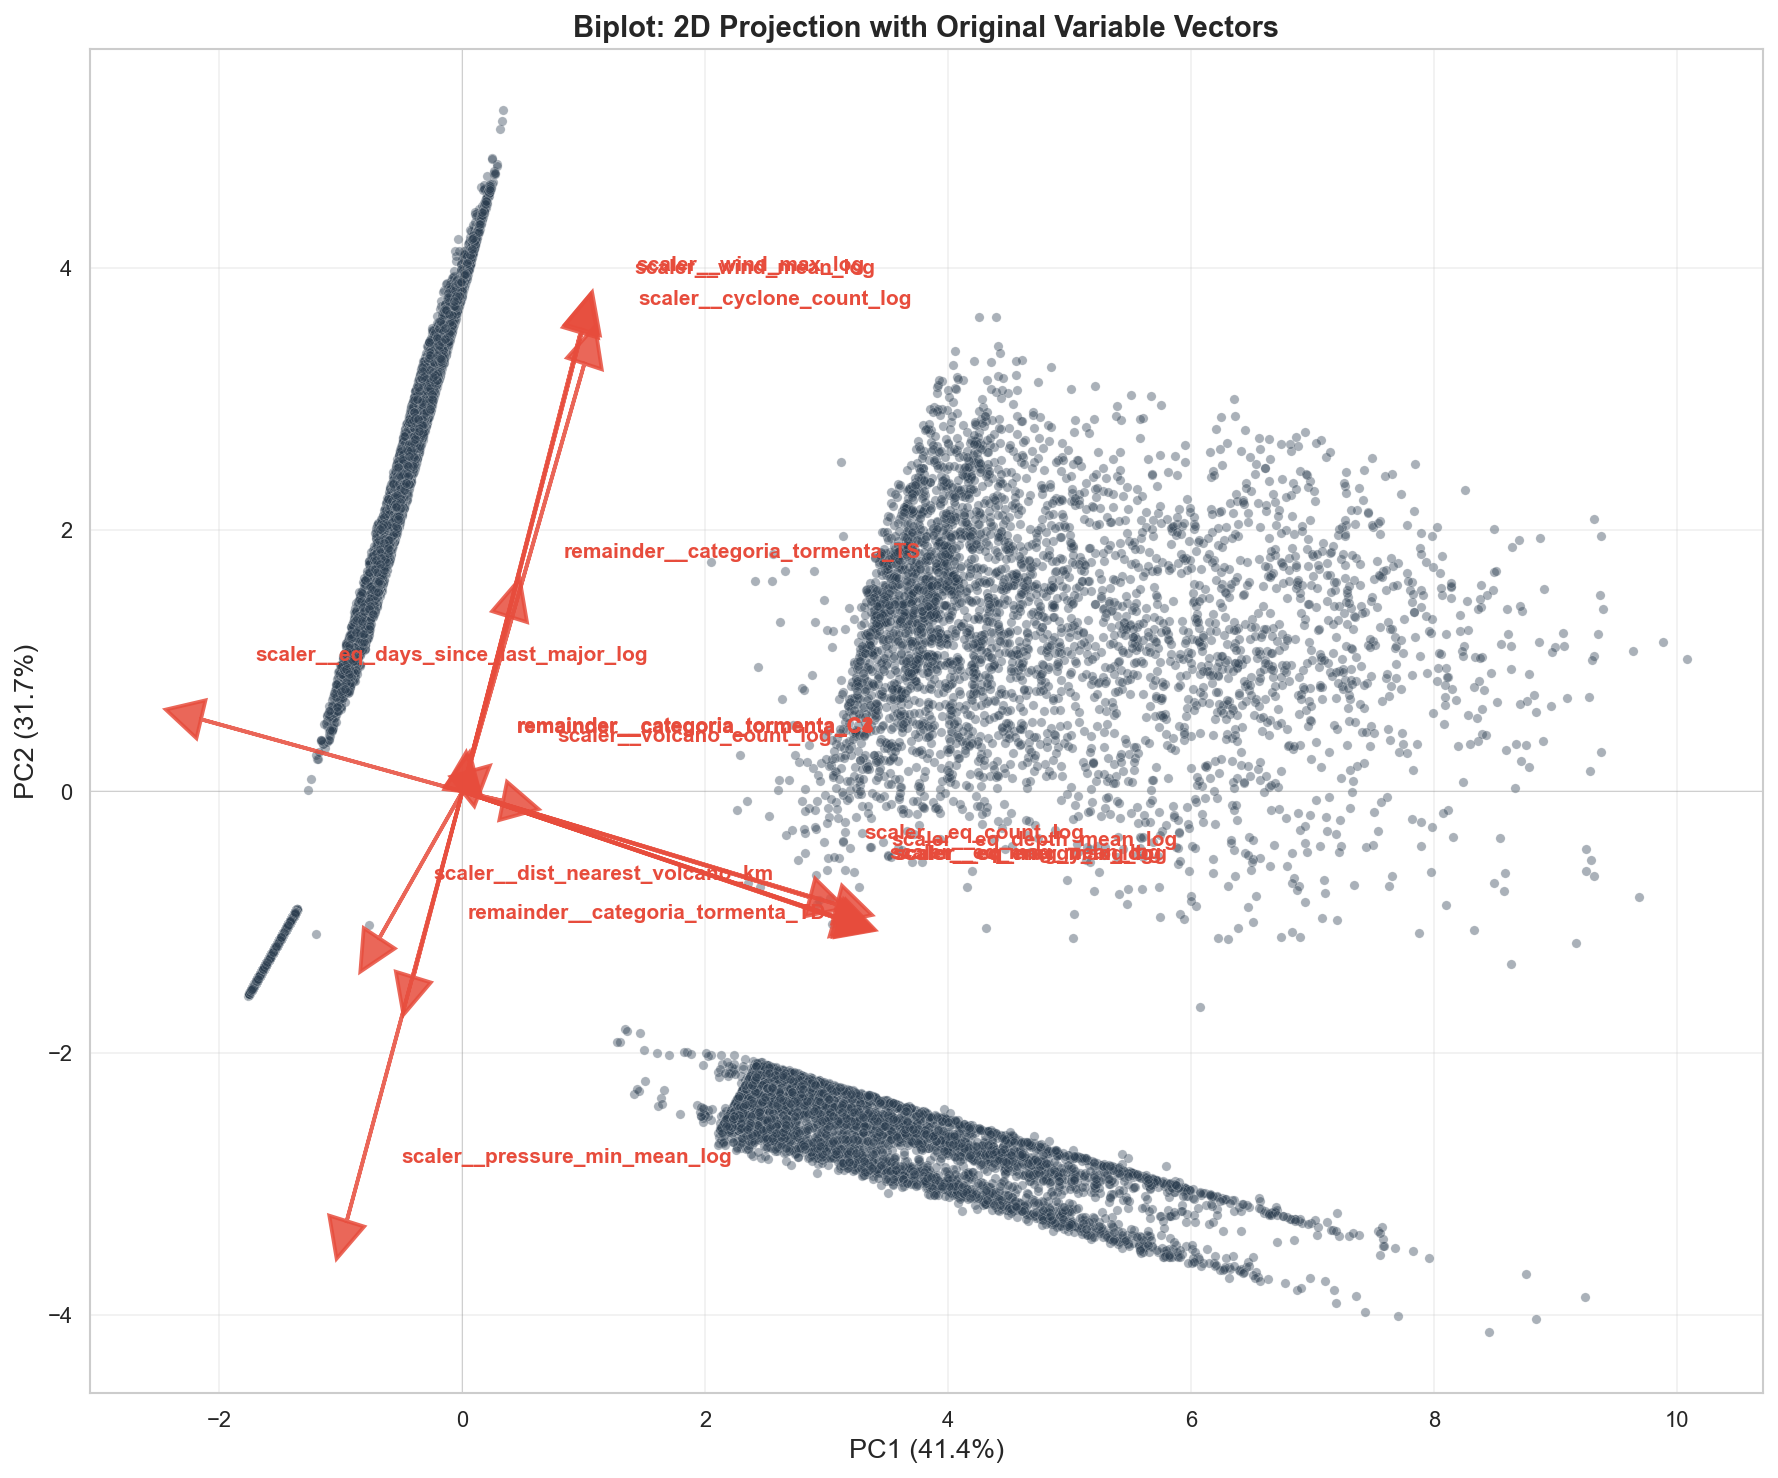

In [15]:
from src.preprocessing import transform_new_data
X_trans = transform_new_data(pipeline, df_raw)
try:
    feat_names = list(pipeline.named_steps["scaler"].get_feature_names_out())
except Exception:
    feat_names = [f"V{i}" for i in range(X_trans.shape[1])]

fig = plot_biplot(df_pca, pca, feature_names=feat_names, save_path="figures/biplot.png")
plt.show()

### 6.4 Loadings Heatmap — Variable Contribution per Component

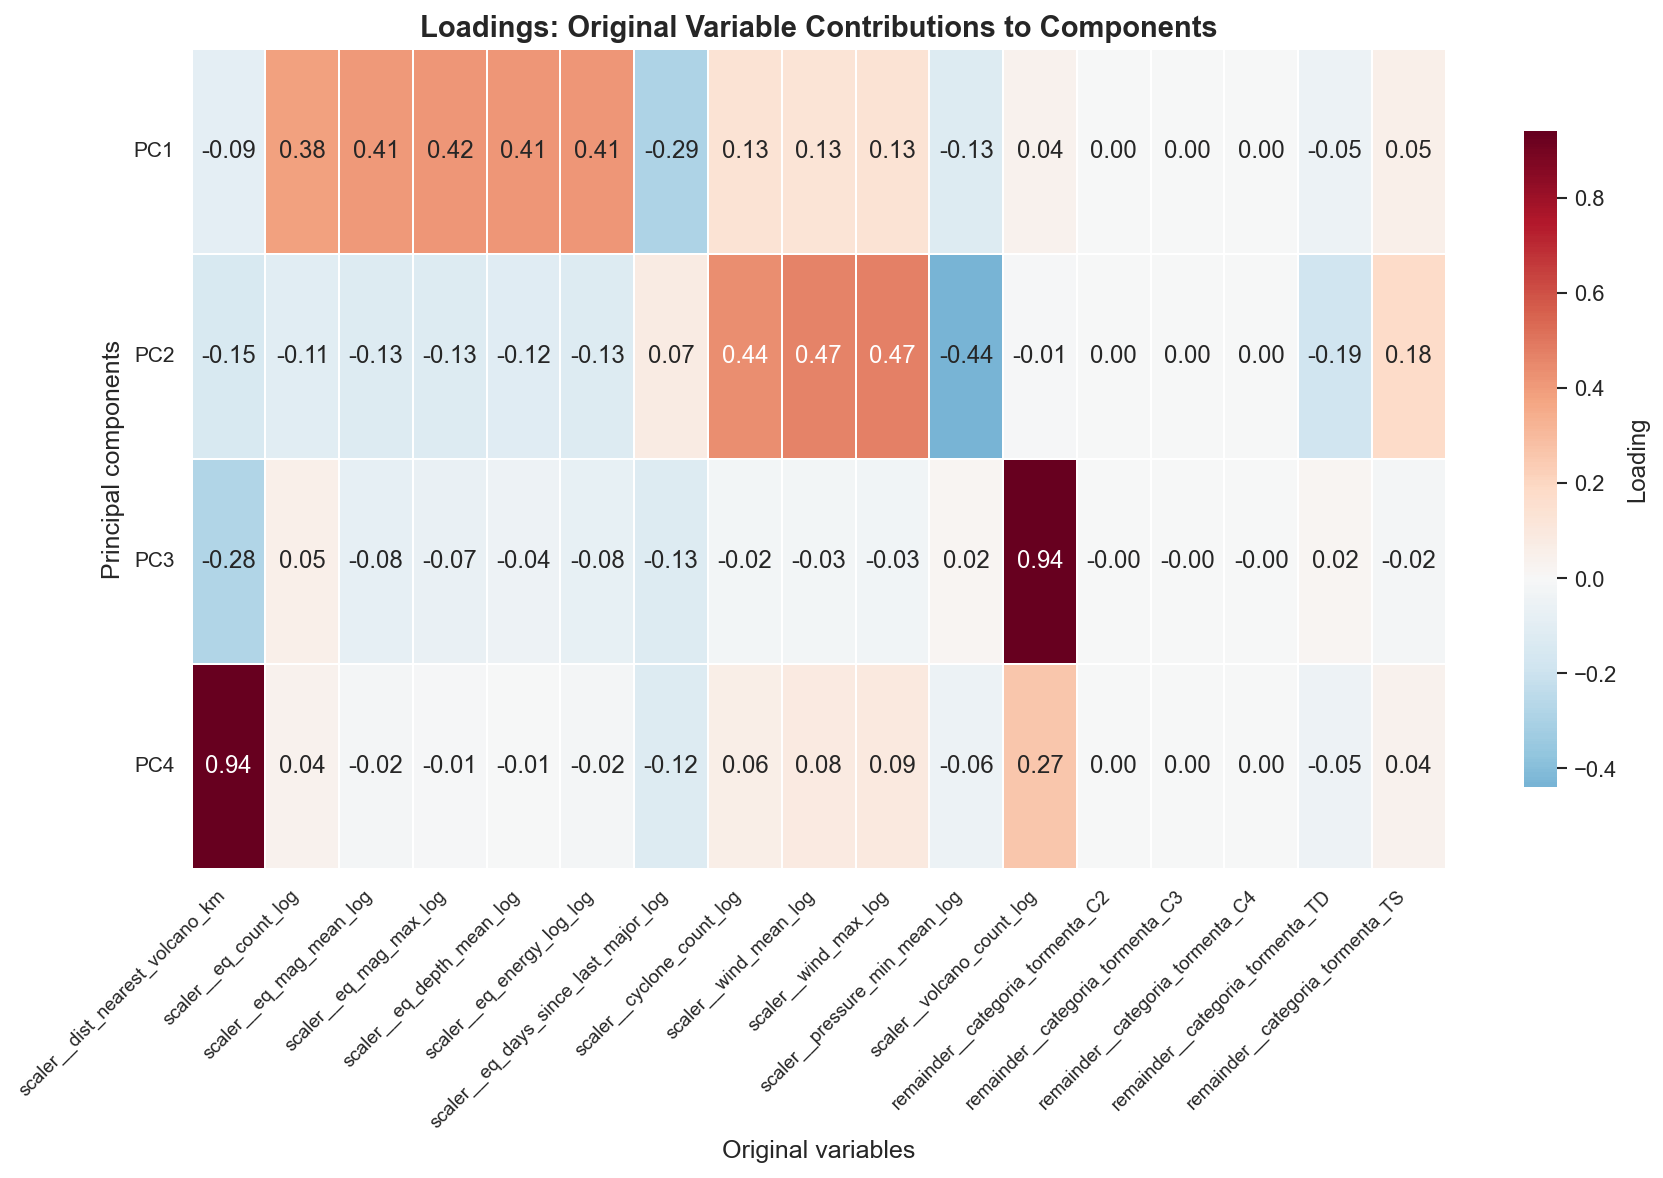

In [16]:
fig = plot_loadings_heatmap(
    pca, feature_names=feat_names,
    n_components=min(6, n_keep),
    save_path="figures/loadings_heatmap.png"
)
plt.show()

### 6.5 Principal Components Pairplot

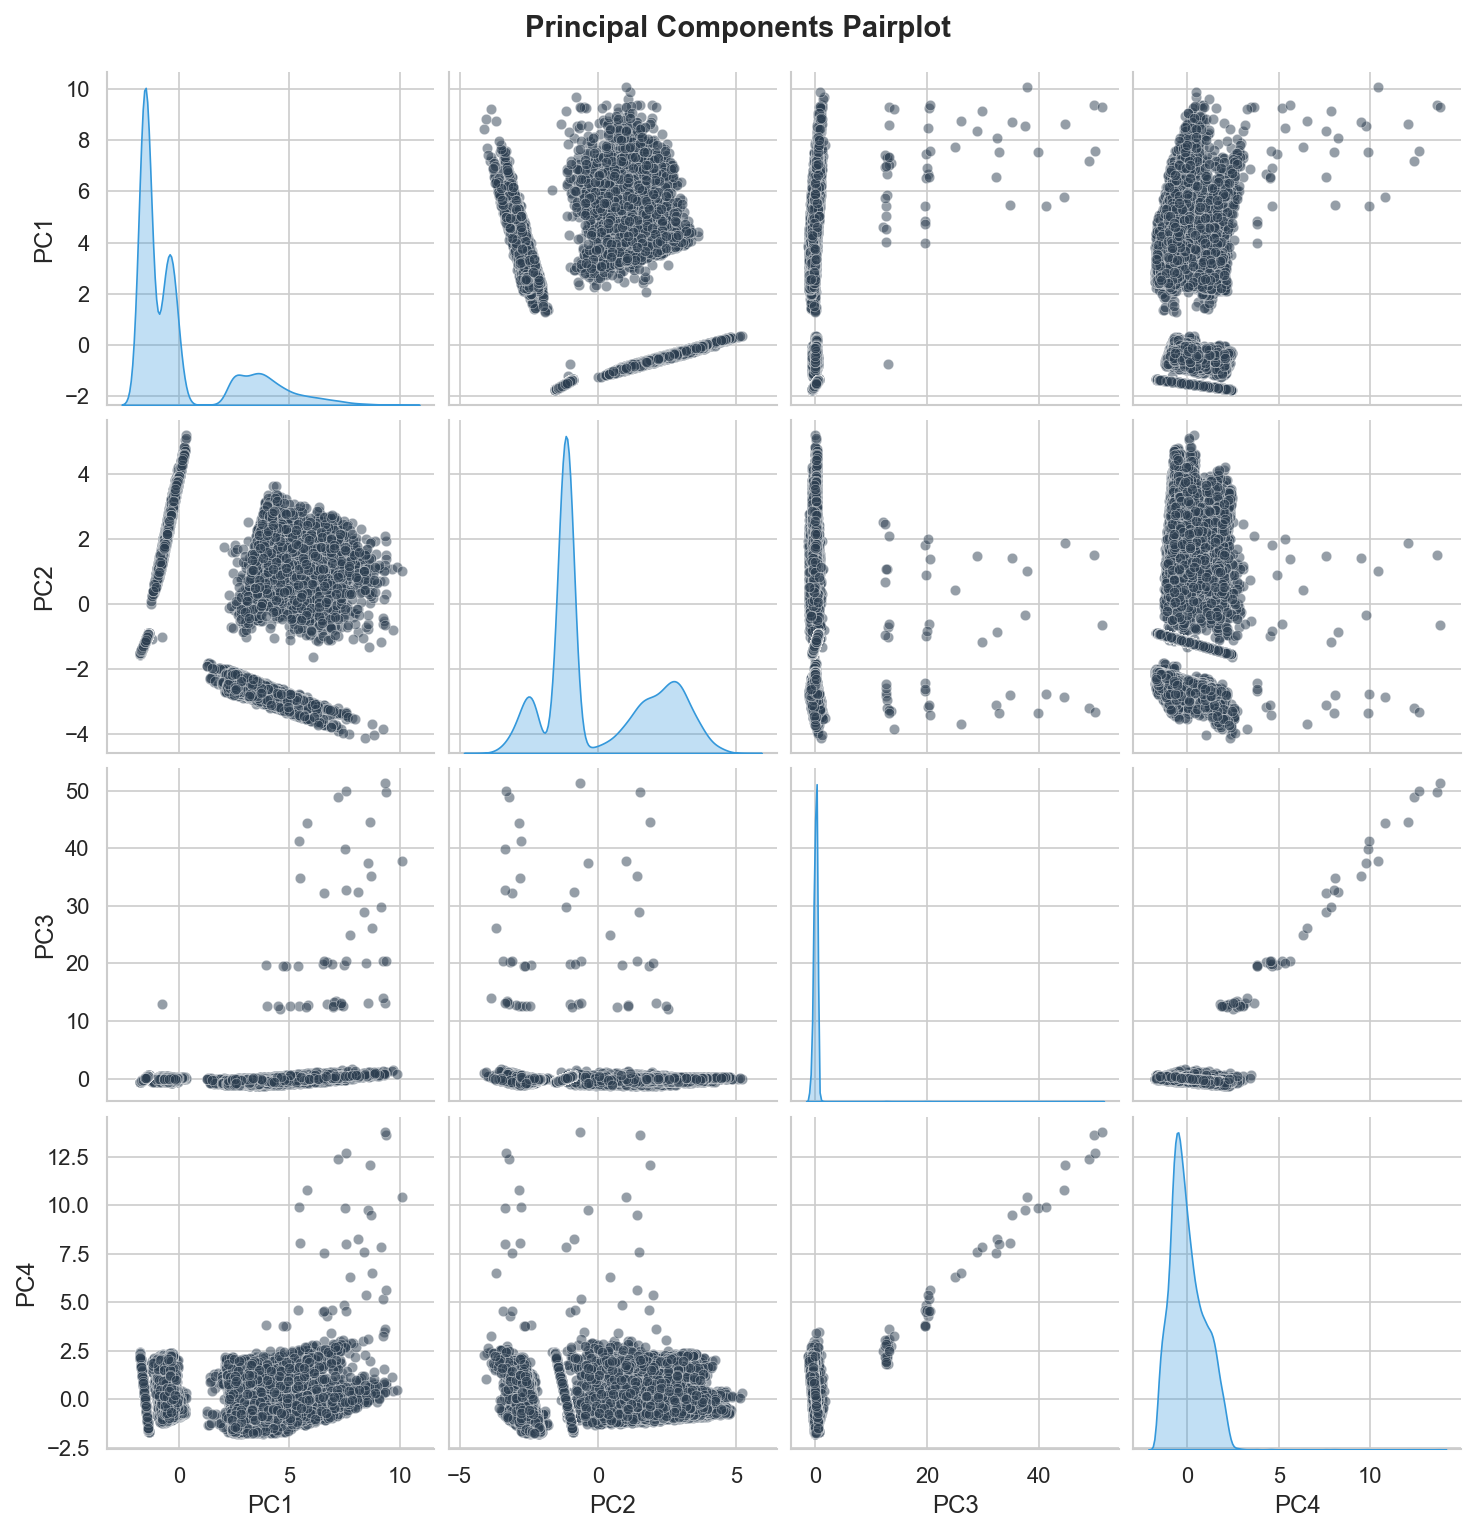

In [17]:
g = plot_pairplot_pca(df_pca, n_components=min(4, n_keep), save_path='figures/pairplot_pca.png')
plt.show()

### 6.6 Interactive 3D PCA (Plotly)

In [18]:
plot_pca_3d(df_pca, pca_model=pca, save_path='figures/pca_3d.html')
print('3D PCA saved to figures/pca_3d.html')

3D PCA saved to figures/pca_3d.html


### 6.7 Interactive 2D PCA (Plotly)

In [19]:
plot_pca_interactive(df_pca, pca_model=pca, save_path='figures/pca_interactivo.html')
print('Interactive 2D PCA saved to figures/pca_interactivo.html')

Interactive 2D PCA saved to figures/pca_interactivo.html


## 7. Geographical Risk Map (Folium)

In [20]:
df_mapa = df_raw[["lat", "lon"] + features].copy()
df_mapa["PC1"] = df_pca["PC1"].values

plot_risk_map(
    df_mapa, lat_col="lat", lon_col="lon", color_col="PC1",
    popup_cols=["magnitud_max_sismo", "viento_max_ciclones", "elevacion_volcan"],
    radius_scale=2.0, save_path="figures/mapa_riesgo.html"
)
print("Risk map saved to figures/mapa_riesgo.html")

Risk map saved to figures/mapa_riesgo.html


## 8. Export Processed Data

In [22]:
os.makedirs("data/processed", exist_ok=True)
df_pca.to_csv("data/processed/dataset_pca.csv", index=False)
df_scaled.to_csv("data/processed/dataset_scaled.csv", index=False)

loaded = load_pipeline("models/pipeline_riesgo.joblib")
X_test = transform_new_data(loaded, df_raw.head(5))
print("Pipeline reloaded and tested successfully.")
print(f"Input: 5 rows -> Output: {X_test.shape[1]} PCA components")
print(f"\nFinal PCA shape: {df_pca.shape}")
print(f"Final scaled shape: {df_scaled.shape}")
print("\nFiles exported:")
print("  - data/processed/dataset_pca.csv")
print("  - data/processed/dataset_scaled.csv")
print("  - models/pipeline_riesgo.joblib")

Pipeline reloaded and tested successfully.
Input: 5 rows -> Output: 4 PCA components

Final PCA shape: (41162, 4)
Final scaled shape: (41162, 17)

Files exported:
  - data/processed/dataset_pca.csv
  - data/processed/dataset_scaled.csv
  - models/pipeline_riesgo.joblib


## 9. Summary — Ready for Duo C (Clustering)

The output feeds into:
- **Persona 5** (K-Means, DBSCAN) — use dataset_pca.csv
- **Persona 6** (stability, business interpretation) — use scaled features + loadings

### Key design decisions
| Decision | Rationale |
|---|---|
| target_variance = 0.85 | Balances dimensionality reduction vs information loss |
| log1p on high-skew columns | Reduces leverage of extremes without discarding them |
| Outliers preserved | Geological extremes are signal, not noise |
| StandardScaler | Required for distance-based clustering (K-Means, DBSCAN) |
| Pipeline exported via joblib | Reproducible transforms for new data without refitting |

### Deliverables
- PCA components matrix (n cells x k components)
- Scaled feature matrix (n cells x p features)
- Trained sklearn pipeline (joblib)
- Interactive visualisations (HTML): 2D, 3D PCA + risk map
- Static figures (PNG): distributions, correlation, variance, biplot, loadings, pairplot
